# Week 2 — Notebook 3: Comparative Analysis (Bonus)

This notebook contains analysis questions that require you to **write code and explain your findings**.

For each question:
1. Write your code in the empty cell below the question
2. Add a short written answer (2–4 sentences) in a markdown cell after your output

You may load processed CSVs from `data/processed/` or recompute indicators directly from `data/raw/`.

> Charts must have titles, axis labels, and legends. Written answers must reference specific dates or numbers from your output.

---

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

def safe_symbol(s):
    return s.replace('^','').replace('.',  '_').replace('=','_').replace('-','_')

def load_features(symbol):
    return pd.read_csv(PROCESSED_DIR / f'{safe_symbol(symbol)}_features.csv',
                       parse_dates=['date'], index_col='date')

print('Setup done.')

Setup done.


---

## Q1 — Which US stock had the highest average SMA-20 over 2020–2024?

Load the processed features for `AAPL`, `MSFT`, `NVDA`, `TSLA`, and `SPY`.
Filter to **2020-01-01 → 2024-12-31**.
For each symbol, compute the mean of its `sma_ratio_20` over that period (not the raw SMA value — the ratio tells you how far above/below average each stock typically trades).
Display results as a **horizontal bar chart**, sorted from highest to lowest.

**Answer in a markdown cell:** Which stock was most consistently above its 20-day average? What does a persistently positive sma_ratio suggest about its trend?

<BarContainer object of 5 artists>

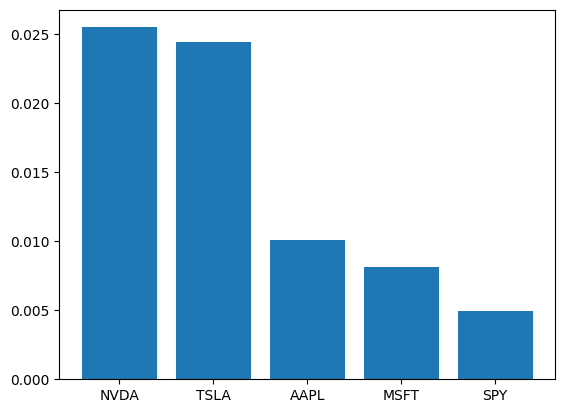

In [3]:
# Your code here
US_SYMBOL = ['AAPL','MSFT','NVDA','TSLA','SPY']

avg_sma = {}
for sym in US_SYMBOL:
    df = load_features(sym)
    sma_ratio_20 = df.loc[(df.index>pd.Timestamp('2020-01-01')) & (df.index<pd.Timestamp('2024-12-31')),'sma_ratio_20']
    sma_20_mean = sma_ratio_20.mean()
    avg_sma[sym] = sma_20_mean

avg_sma = dict(sorted(avg_sma.items(), key=lambda x:x[1], reverse=True))
plt.bar(avg_sma.keys(), avg_sma.values())

*NVDA*

---

## Q2 — Side-by-side RSI comparison: one Indian stock, one US stock, one crypto

Choose one symbol from each group:
- India: `RELIANCE.NS` or `TCS.NS`
- US: `AAPL`, `MSFT`, or `NVDA`
- Crypto: `BTC-USD` or `ETH-USD`

Plot their `rsi_14` in a **3-row subplot** sharing the x-axis, covering the most recent **two full years** of data.
Draw dashed lines at 0.70 (overbought) and 0.30 (oversold) on each panel.

**Answer in a markdown cell:** Which asset class spends the most time in extreme RSI territory (above 0.70 or below 0.30)? Give a possible reason.

TCS_NS Days : 99
MSFT Days : 86
ETH_USD Days : 72


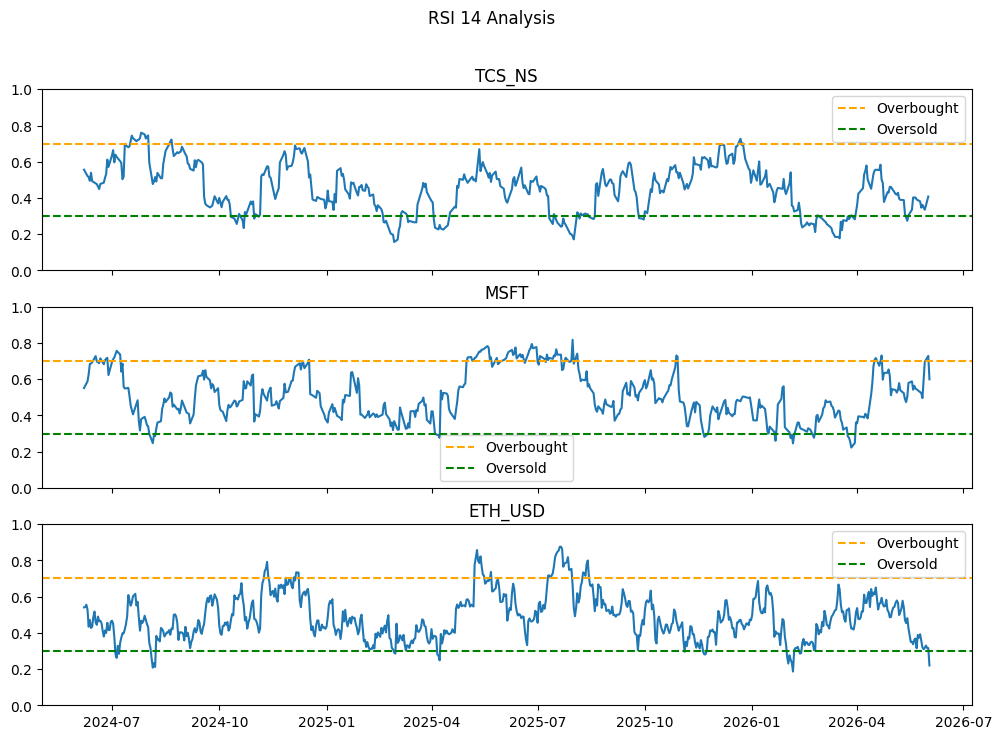

In [4]:
# Your code here
SYMBOL = ['TCS.NS','MSFT','ETH-USD']

fig, ax = plt.subplots(3,1, figsize=(12,8), sharex=True)
fig.suptitle('RSI 14 Analysis')
idx = 0

for sym in SYMBOL:
    df = load_features(sym)
    rsi_14_recent = df.loc[df.index>pd.Timestamp.now()-pd.DateOffset(years=2),'rsi_14']
    ax[idx].plot(rsi_14_recent.index, rsi_14_recent.values)
    ax[idx].set_title(f"{safe_symbol(sym)}")
    ax[idx].set_ylim(0,1)
    ax[idx].axhline(0.7, linestyle='--', color='orange',label='Overbought')
    ax[idx].axhline(0.3, linestyle='--', color='green',label='Oversold')
    ax[idx].legend()
    idx += 1
    days = len(rsi_14_recent.loc[(rsi_14_recent.values>0.7) | (rsi_14_recent.values<0.3)])
    print(f"{safe_symbol(sym)} Days : {days}")



*MSFT - Due to increased popularity of MSFT in those days, it was overbought*

---

## Q3 — MACD histogram comparison: AAPL vs MSFT vs NVDA

Plot the `macd_hist` column for all three symbols in a **3-row subplot** (shared x-axis, last two years).
Colour bars **green** when positive and **red** when negative so crossovers are visually clear.

Then count the number of histogram sign changes per symbol (i.e. how often does the bar switch from positive to negative or vice versa?).

**Answer in a markdown cell:** Which stock has the most sign changes? What does frequent sign-changing imply about that stock's trend consistency?

AAPL Times : 40
MSFT Times : 41
NVDA Times : 39


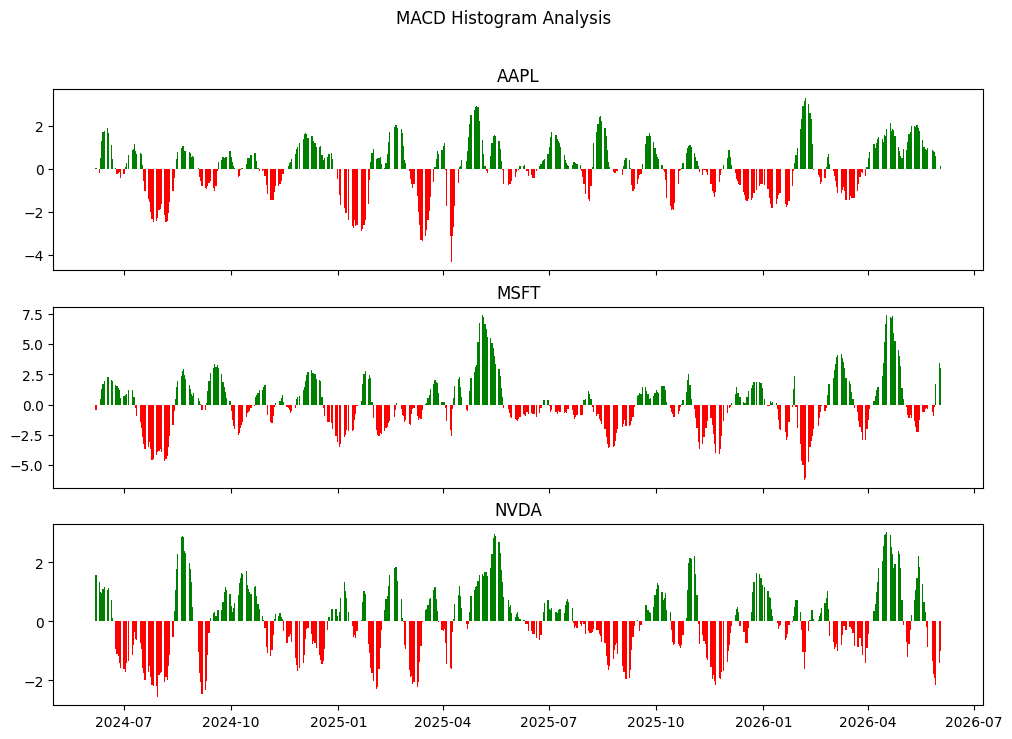

In [5]:
# Your code here
SYMBOL = ['AAPL','MSFT','NVDA']

fig, ax = plt.subplots(3,1, figsize=(12,8), sharex=True)
fig.suptitle('MACD Histogram Analysis')
idx = 0

for sym in SYMBOL:
    df = load_features(sym)
    macd_hist = df['macd']-df['macd_signal']
    macd_hist_recent = macd_hist.loc[macd_hist.index>pd.Timestamp.now()-pd.DateOffset(years=2)]
    ax[idx].bar(macd_hist_recent.index,macd_hist_recent.values, color=np.where(macd_hist_recent.values>=0,'green','red'),width=1)
    ax[idx].set_title(f"{safe_symbol(sym)}")
    number = ((macd_hist_recent*macd_hist_recent.shift(1)) < 0).sum()
    print(f"{safe_symbol(sym)} Times : {number}")
    idx += 1

*AAPL - frequent sign change implies no consistent trend (no clear direction)*

---

## Q4 — Volatility comparison: which symbol has the widest Bollinger Bands on average?

Load processed features for at least **six symbols** spanning at least two markets.
Compute the **mean `bb_width`** for each symbol over its full available history.
Plot as a sorted bar chart.

Then for the **most volatile symbol**, plot its close price with Bollinger Bands and highlight the top-10% widest-band periods with a shaded background.

**Answer in a markdown cell:** What event or characteristic of that asset explains why its bands are wider than the others?

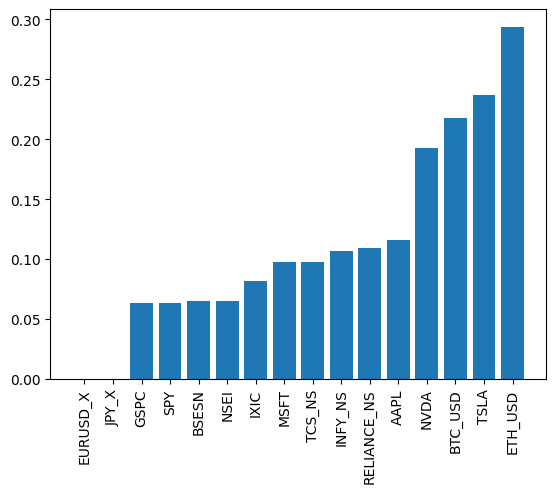

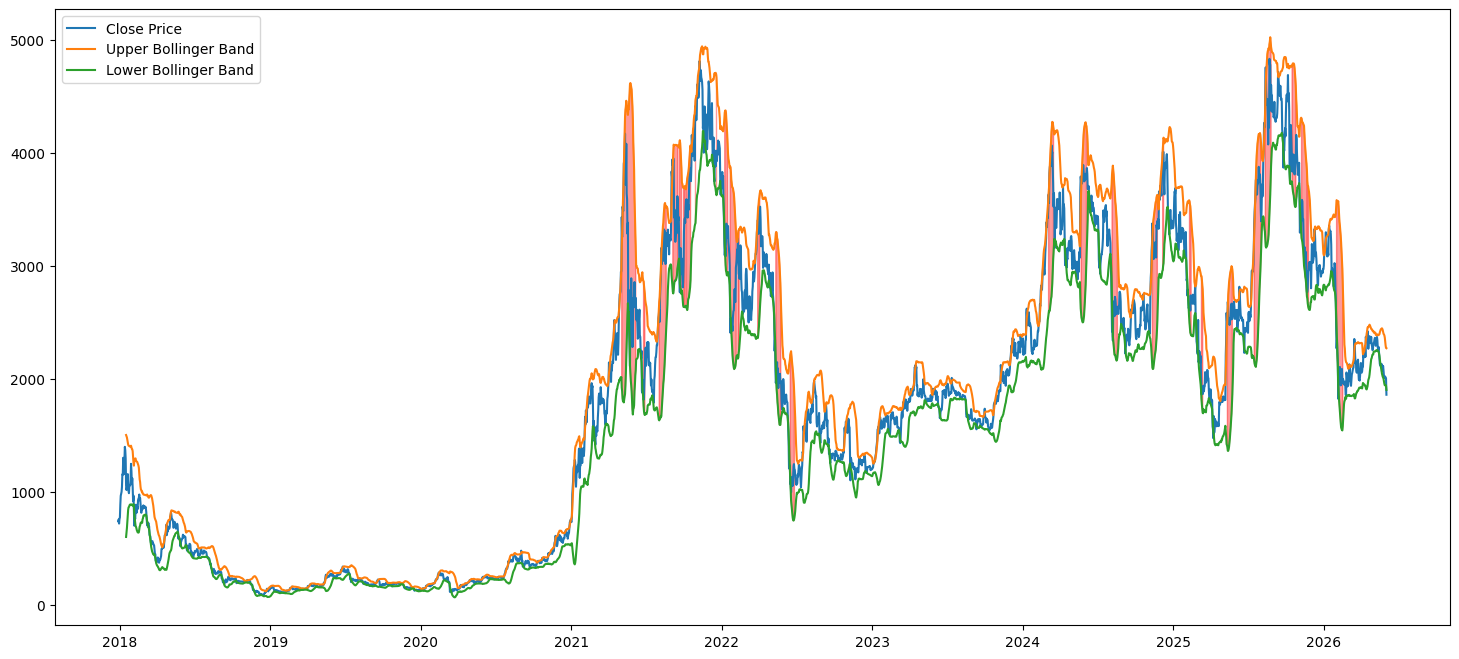

In [33]:
# Your code here
mean_bb_with = {}

for csv_path in PROCESSED_DIR.iterdir():
    sym = str(csv_path).split('/')[-1][:-13]
    df = load_features(sym)

    mean_bb_with[sym] = df['bb_width'].mean()

    if pd.isna(mean_bb_with[sym]):
        mean_bb_with[sym] = 0
    
mean_bb_with = dict(sorted(mean_bb_with.items(), key=lambda x:x[1],reverse=False))
plt.bar(mean_bb_with.keys(), mean_bb_with.values())
plt.xticks(rotation=90)
plt.show()

max_symbol = max(mean_bb_with,key=mean_bb_with.get)

# Plotting 
max_df_raw = pd.read_csv(f"{RAW_DIR}/{max_symbol}.csv")
max_df_raw = max_df_raw.set_index('date')
max_df_raw.index = pd.to_datetime(max_df_raw.index)

max_df_processed = load_features(max_symbol)

close = max_df_raw['close'].loc[max_df_processed.index]
# close = close.loc[close.index>'2025-01-01']

rolling_std    = close.rolling(window=20).std()
sma_20 = close.rolling(window=20).mean()
bb_upper =  sma_20 + 2*rolling_std
bb_lower =  sma_20 - 2*rolling_std

bb_width = bb_upper-bb_lower

plt.figure(figsize=(18,8))
plt.plot(close.index,close.values,label='Close Price')
plt.plot(bb_upper.index,bb_upper.values,label='Upper Bollinger Band')
plt.plot(bb_lower.index,bb_lower.values,label='Lower Bollinger Band')
plt.fill_between(close.index,bb_upper, bb_lower,where=(bb_width>=bb_width.quantile(0.9)), color='red',alpha=0.4)
plt.legend()
plt.show()

*ETH_USD* <br>
*Reason - Crypto markets trade 24/7 exhibiting price swings, they also depends on news and are protocol-level driven*

---

## Q5 — Why was RSI elevated? (Three companies, written analysis)

Choose **three companies** — one from each market group (India / US / Crypto).

For each company, find the **longest consecutive streak of days with `rsi_14` > 0.65**.
Report: start date, end date, streak length in days, and the price gain (%) during that streak.

For each company, write **at least 3 sentences** explaining what likely drove the sustained momentum. Consider: earnings releases, macro tailwinds, sector rotation, or broader market risk-on periods. Use the dates you found to anchor your reasoning.

Plot the price and RSI together for each company, with the identified streak highlighted.

                           Start                  End Streak     Gain %
RELIANCE_NS  2020-06-15 00:00:00  2020-07-30 00:00:00     31  29.606848
AAPL         2019-10-11 00:00:00  2019-11-29 00:00:00     35  13.554077
ETH_USD      2024-02-12 00:00:00  2024-03-14 00:00:00     32  51.634218


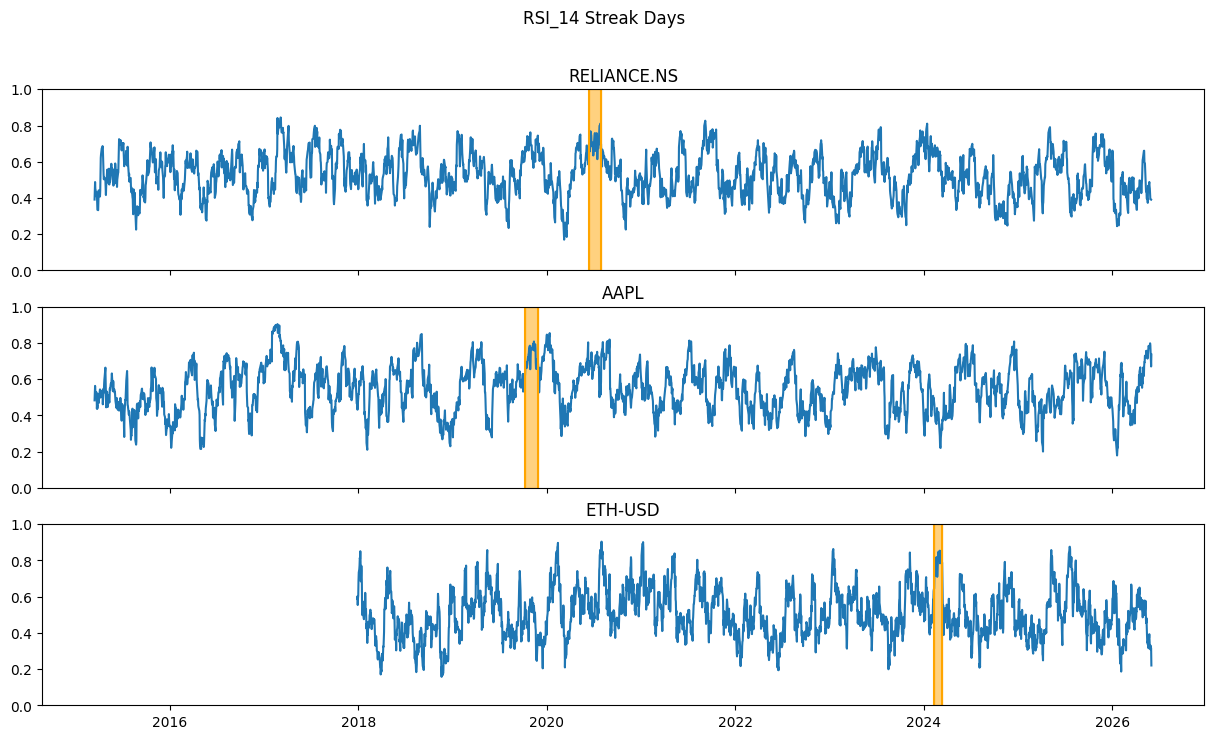

In [117]:
# Your code here — find longest overbought streak per company
SYMBOL = ['RELIANCE.NS','AAPL','ETH-USD']

report = {}

fig, ax = plt.subplots(3,1,figsize=(15,8),sharex=True)
plt.suptitle("RSI_14 Streak Days")
idx = 0

for sym in SYMBOL:
    df = load_features(sym)
    rsi_14 = df['rsi_14'].loc[df['rsi_14']>0.65]
    start = None
    max_start = None
    max_end = None
    max_streak = 0
    streak = 0

    # crypto trades 7 days a week, equities 5
    is_crypto = sym in ['ETH-USD']
    max_gap = pd.Timedelta(days=1) if is_crypto else pd.Timedelta(days=3)
    for i in range(len(rsi_14.index)):

        if i==0:
            start = rsi_14.index[i]
            streak = 1
            continue

        if (rsi_14.index[i] - rsi_14.index[i-1]) <= max_gap:
            streak += 1
        else:
            if streak > max_streak:
                max_start = start
                max_end = rsi_14.index[i-1]
                max_streak = streak

            streak = 1
            start = rsi_14.index[i]
    
    # ✅ check final streak
    if streak > max_streak:
        max_start = start
        max_end = rsi_14.index[-1]
        max_streak = streak

    raw_csv = pd.read_csv(RAW_DIR/f'{safe_symbol(sym)}.csv')
    raw_csv['date'] = pd.to_datetime(raw_csv['date'])
    
    raw_csv_close = raw_csv.loc[(raw_csv['date']>max_start)&(raw_csv['date']<max_end),'close']
    gain_pct = ((raw_csv_close.iloc[-1]/raw_csv_close.iloc[0])-1)*100

    report[safe_symbol(sym)]={'Start':max_start,
                              'End':max_end,
                              'Streak':max_streak,
                              'Gain %':gain_pct}
    ax[idx].plot(df.index, df['rsi_14'], label='RSI_14')
    ax[idx].set_title(sym)
    ax[idx].axvline(max_start,color='orange')
    ax[idx].axvline(max_end,color='orange')
    ax[idx].axvspan(max_start,max_end, color='orange',alpha=0.5)
    ax[idx].set_ylim(0,1)
    idx += 1
    
    
rp = pd.DataFrame(report).T

print(rp)

*RELIANCE.NS (India) — Between June–July 2020, Reliance announced massive investments from Facebook and Google into its Jio platform, which excited investors and drove the stock up strongly. The broader market was also recovering from the COVID crash, adding to the momentum.*

*AAPL (US) — In October–November 2019, Apple reported better than expected earnings, with its services business (App Store, Apple Music etc.) growing fast. The overall market was also doing well due to Fed rate cuts and US-China trade optimism, keeping buying pressure high for weeks.*

*ETH_USD (Crypto) — In February–March 2024, the entire crypto market was rallying after Bitcoin ETFs got approved in the US for the first time, bringing in a flood of new investors. ETH rode that wave, and with the Bitcoin halving approaching in April, sentiment was extremely bullish across the board.*

---

## Q6 — Why was ATR ratio highest in that month? (Three companies)

Using the same three companies from Q5:

For each company, find the **calendar month with the highest mean `atr_ratio`**.
Plot the daily `atr_ratio` for the full year containing that month, with the peak month highlighted using `fill_between` or `axvspan`.

Write **at least 3 sentences per company** explaining the spike. Consider: earnings surprises, central bank decisions, geopolitical events, or crypto-specific catalysts. ATR captures both intraday swings and overnight gap risk — comment on which you think dominated.

RELIANCE_NS : April
AAPL : March
ETH_USD : February


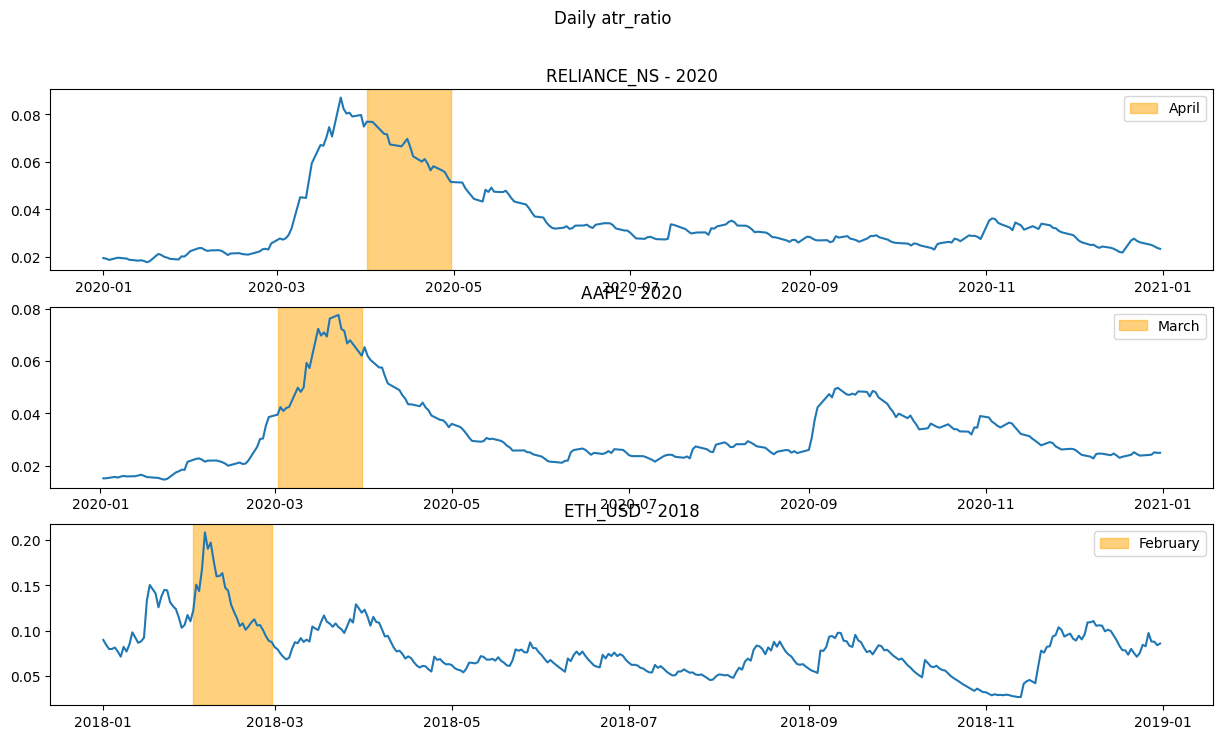

In [195]:
# Your code here
SYMBOL = ['RELIANCE.NS','AAPL','ETH-USD']

fig, ax = plt.subplots(3,1,figsize=(15,8))
plt.suptitle('Daily atr_ratio')
idx = 0

for sym in SYMBOL:
    df = load_features(sym)
    monthly_atr_ratio = df['atr_ratio'].resample('ME').mean()
    max_month = monthly_atr_ratio.idxmax().strftime('%B')
    max_month_year = monthly_atr_ratio.idxmax().year
    print(f'{safe_symbol(sym)} : {max_month}')
    daily_atr = df['atr_ratio'].loc[df.index.year==max_month_year]
    atr_month = daily_atr.loc[daily_atr.index.strftime('%B')==max_month]
    ax[idx].plot(daily_atr.index,daily_atr.values)
    ax[idx].set_title(f'{safe_symbol(sym)} - {max_month_year}')
    ax[idx].axvspan(atr_month.index[0],atr_month.index[-1],color='orange', alpha=0.5,label=f'{max_month}')
    ax[idx].legend()
    idx +=1
plt.show()


*RELIANCE.NS — The ATR ratio spiked in April 2020 because of the COVID-19 crash combined with the historic oil price collapse (crude briefly went negative). As a major petrochemicals company, Reliance was hit hard by both. Markets were swinging wildly day to day on lockdown news and stimulus announcements, making overnight gap risk the dominant factor.*

*AAPL — March 2020 was the peak of the COVID crash — the fastest bear market in history. Apple faced fears about its China-based supply chain shutting down and consumers not buying phones. Massive overnight gaps driven by daily pandemic news (lockdowns, Fed emergency cuts) were the primary driver of the high ATR.*

*ETH_USD — ETH had just peaked at ~$1400 in January 2018 and was crashing hard. The trigger was regulatory crackdowns in South Korea and China on crypto exchanges, combined with retail investors panic selling after the bubble burst. Since crypto trades 24/7, this was pure intraday volatility — no overnight gaps, just relentless around-the-clock selling pressure.*

---

## Q7 — Does a high Stochastic %K always mean the stock is overbought?

Compute the fraction of days with `stoch_k` > 0.80 for each of your three companies.
Bar-chart the results.

Then for the company with the **highest fraction**, plot its `stoch_k` alongside `sma_ratio_50` for the last two years on a dual-panel chart.

**Answer in a markdown cell:** A high stochastic can mean (a) the stock is genuinely overbought and due for reversal, or (b) it is in a strong uptrend and keeps closing near its highs. Use the `sma_ratio_50` panel to argue which case applies here.

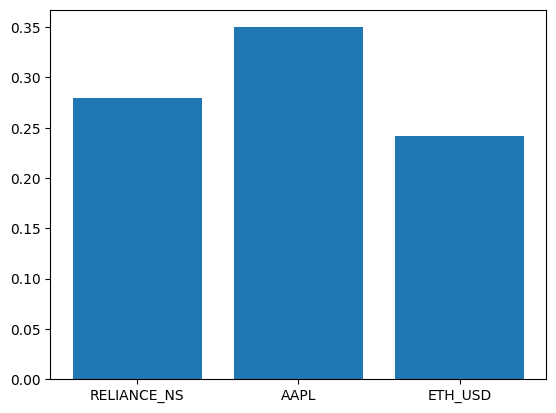

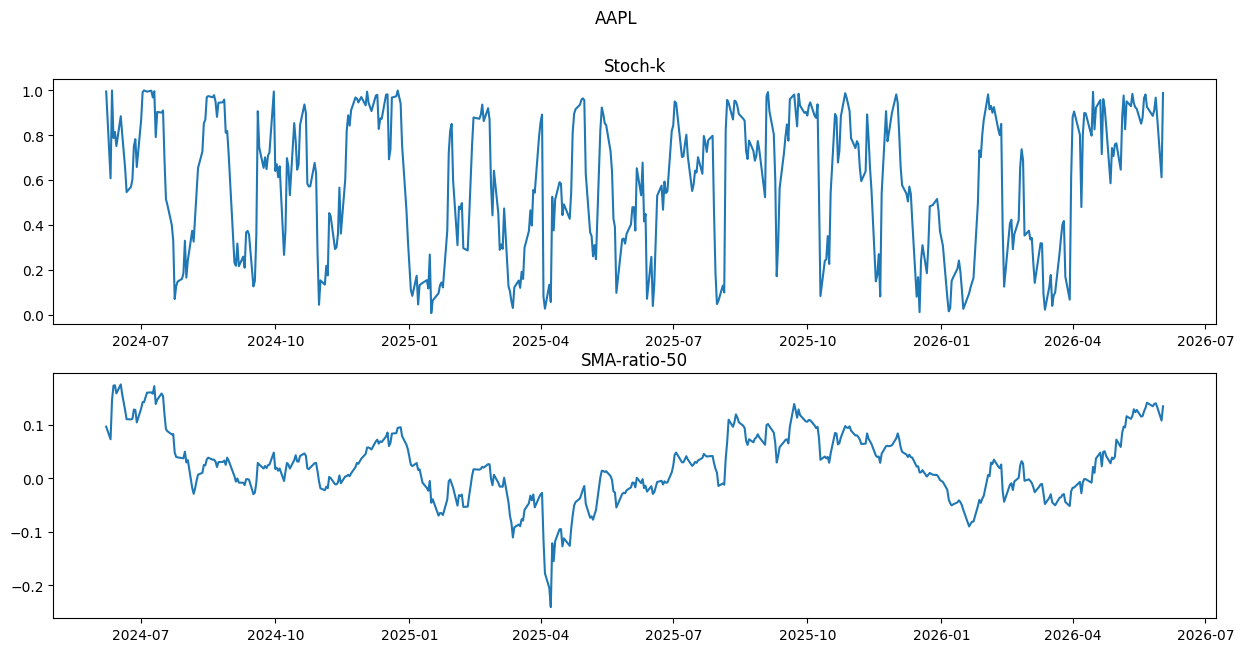

In [194]:
# Your code here
SYMBOL = ['RELIANCE.NS','AAPL','ETH-USD']

fraction = {}

for sym in SYMBOL:
    df = load_features(sym)
    stock_k = df['stoch_k']
    total_days = stock_k.shape[0]
    stock_k = stock_k[stock_k>0.8]
    required_days = stock_k.shape[0]
    fraction_days = required_days/total_days
    fraction[safe_symbol(sym)] = fraction_days

plt.bar(fraction.keys(), fraction.values())
max_fraction_symbol = max(fraction,key=fraction.get)

max_df = load_features(max_fraction_symbol)

max_df = max_df.loc[max_df.index > pd.Timestamp.now() - pd.DateOffset(years=2)]

fig, ax = plt.subplots(2,1,figsize=(15,7))
plt.suptitle(f'{max_fraction_symbol}')
ax[0].plot(max_df.index,max_df['stoch_k'])
ax[0].set_title('Stoch-k')

ax[1].plot(max_df.index,max_df['sma_ratio_50'])
ax[1].set_title('SMA-ratio-50')

plt.show()

*No, a high Stochastic %K doesn't always mean the stock is overbought.* <br><br>
*%K just measures where the price is relative to its recent range — so in a strong uptrend, the stock keeps closing near its highs every day, keeping %K elevated without any reversal.* <br><br>
*Looking at AAPL's sma_ratio_50, it trends upward consistently from mid-2024 through 2026, confirming the price stayed above its 50-day average for a long time. This means AAPL's high %K was due to a genuine uptrend, not an overbought condition. Using %K alone as a sell signal here would have kicked you out of a strong trend way too early.*

---
